In [53]:
library(lme4)
library(emmeans)

Warning message:
"package 'emmeans' was built under R version 4.4.3"
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [ ]:
#### GENERALIZATION ANALYSIS

[1] "Working directory: C:/Users/jacob/water_current_MA/data/dual_generalization"


Contrasts set to contr.sum for the following variables: target_x_label, phase, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm ~ target_x_label * phase + (1 | ppid_full)
Data: df_subset
                Effect        df         F p.value
1       target_x_label 3, 522.15 52.97 ***   <.001
2                phase 1, 522.42 53.24 ***   <.001
3 target_x_label:phase 3, 127.23      1.52    .212
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -14.5 1.99 522    -18.4    -10.6  -7.296  <.0001

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -9.04 5.05 112    -19.1     0.97  -1.789  0.0762

target_x_label = L60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -12.91 5.04 111    -22.9    -2.93  -2.563  0.0117

target_x_label = R30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -15.26 5.07 114    -25.3    -5.22  -3.009  0.0032

target_x_label = R60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -20.81 5.06 113    -30.8   -10.79  -4.114  0.0001

Degrees-o

Contrasts set to contr.sum for the following variables: target_x_label, phase, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm ~ target_x_label * phase + (1 | ppid_full)
Data: df_subset
                Effect        df          F p.value
1       target_x_label 3, 498.98 108.64 ***   <.001
2                phase 1, 500.65 174.98 ***   <.001
3 target_x_label:phase 3, 128.64   6.91 ***   <.001
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -26.2 1.98 500    -30.1    -22.3 -13.225  <.0001

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -16.7 4.96 115    -26.5    -6.83  -3.358  0.0011

target_x_label = L60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -18.0 4.96 115    -27.8    -8.13  -3.620  0.0004

target_x_label = R30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -37.9 5.03 120    -47.9   -27.95  -7.540  <.0001

target_x_label = R60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -32.3 4.97 115    -42.2   -22.47  -6.505  <.0001

Degrees-o

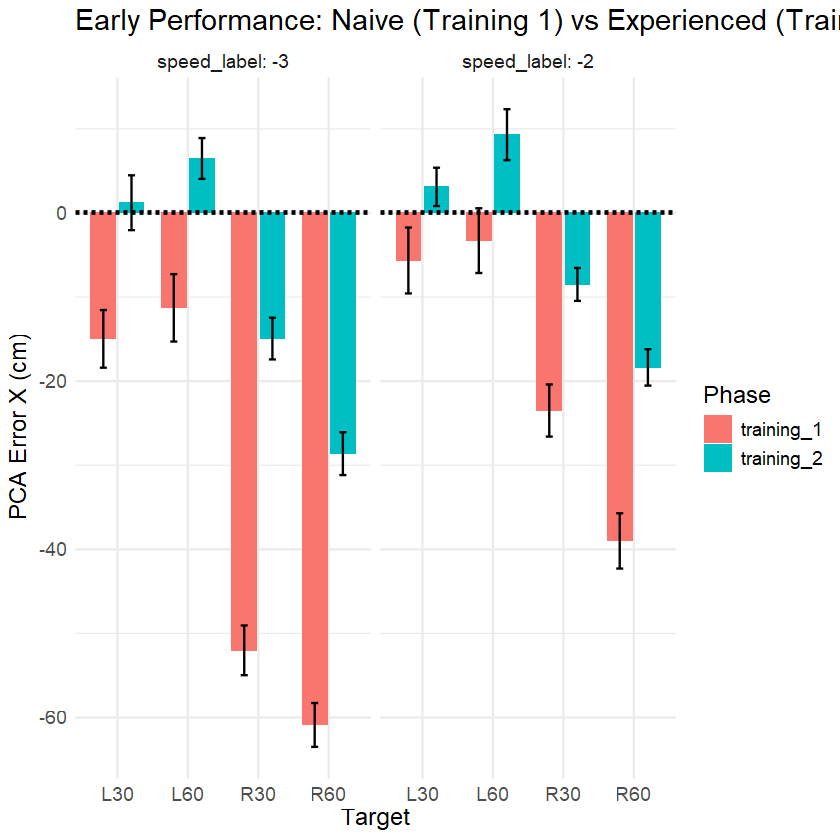

In [83]:
library(afex)
library(emmeans) 

setwd("C:/Users/jacob/water_current_MA/data/single_generalization")
dir <- getwd()
print(paste("Working directory:", dir))

df_single_3 <- read.csv("early_late_phase_PCA_error_projectile_experiment _S1-projectile_experiment_etc_speed_neg3_0_neg2_0.csv")

# Ensure factors
df_single_3$ppid_full <- factor(df_single_3$ppid_full)
df_single_3$speed_label <- factor(df_single_3$speed_label)

# leave out late trials
df_early <- df_dual[df_dual$trial_set == "early", ]
speeds_list <- unique(df_early$speed_label)

for (s in speeds_list) {
  
  df_subset <- df_early[df_early$speed_label == s,]
  df_subset <- droplevels(df_subset) 
    
  mm_gen <- afex::mixed(PCA_error_X_cm ~ target_x_label * phase + (1|ppid_full),
                        data = df_subset, method = "S")
  
  print(afex::nice(mm_gen))
  
  emm_mm_gen <- emmeans(mm_gen, ~ phase)
  emm_by_target <- emmeans(mm_gen, ~ phase | target_x_label)
  
  print(pairs(emm_mm_gen, infer = TRUE))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))
}


library(ggplot2)
library(dplyr)

# Calculate means and standard errors for plotting
plot_data <- df_early %>%
  group_by(speed_label, phase, target_x_label) %>%
  summarise(
    mean_error = mean(PCA_error_X_cm, na.rm = TRUE),
    se_error = sd(PCA_error_X_cm, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# Create the plot
ggplot(plot_data, aes(x = target_x_label, y = mean_error, fill = phase)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_errorbar(aes(ymin = mean_error - se_error, ymax = mean_error + se_error),
                position = position_dodge(width = 0.8), width = 0.2) +
  facet_wrap(~ speed_label, labeller = label_both) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1) + # 0 line
  theme_minimal() +
  labs(
    title = "Early Performance: Naive (Training 1) vs Experienced (Training 2)",
    x = "Target",
    y = "PCA Error X (cm)",
    fill = "Phase"
  ) +
  theme(text = element_text(size = 14))

In [ ]:
# OVERALL LEARNING (EARLY VS LATE) ANALYSIS

[1] "Working directory: C:/Users/jacob/water_current_MA/data/dual_generalization"


Contrasts set to contr.sum for the following variables: target_x_label, phase, trial_set, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm ~ target_x_label * phase * trial_set + (1 | ppid_full)
Data: df_subset
                          Effect         df         F p.value
1                 target_x_label 3, 1146.71 74.15 ***   <.001
2                          phase 1, 1146.79 29.70 ***   <.001
3                      trial_set 1, 1146.82 43.21 ***   <.001
4           target_x_label:phase  3, 150.87    2.30 +    .079
5       target_x_label:trial_set 3, 1146.74  9.90 ***   <.001
6                phase:trial_set 1, 1146.93 30.08 ***   <.001
7 target_x_label:phase:trial_set 3, 1146.71      0.67    .569
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -6.69 1.23 1147    -9.09    -4.28  -5.450  <.0001

Results are averaged over the levels of: target_x_label, trial_set 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -3.68 3.05 132    -9.72     2.36  -1.206  0.2300

target_x_label = L60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -3.50 3.05 132    -9.53     2.53  -1.147  0.2533

target_x_label = R30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -8.17 3.05 132   -14.20    -2.13  -2.676  0.0084

target_x_label = R60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -11.40 3.05 132   -17.43    -5.36  -3.736  0.00

Contrasts set to contr.sum for the following variables: target_x_label, phase, trial_set, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm ~ target_x_label * phase * trial_set + (1 | ppid_full)
Data: df_subset
                          Effect         df          F p.value
1                 target_x_label 3, 1319.39 227.44 ***   <.001
2                          phase 1, 1319.95 183.41 ***   <.001
3                      trial_set 1, 1319.60 116.81 ***   <.001
4           target_x_label:phase  3, 131.59   9.36 ***   <.001
5       target_x_label:trial_set 3, 1319.06   7.57 ***   <.001
6                phase:trial_set 1, 1319.47  69.77 ***   <.001
7 target_x_label:phase:trial_set 3, 1319.11     3.18 *    .023
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -15.4 1.14 1320    -17.6    -13.2 -13.543  <.0001

Results are averaged over the levels of: target_x_label, trial_set 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -7.82 4.01 73.6    -15.8    0.181  -1.948  0.0553

target_x_label = L60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -11.23 4.01 73.7    -19.2   -3.227  -2.797  0.0066

target_x_label = R30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -20.66 4.04 75.8    -28.7  -12.605  -5.109  <.0001

target_x_label = R60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -21.96 4.02 74.0    -30.0  -13.949  -5.4

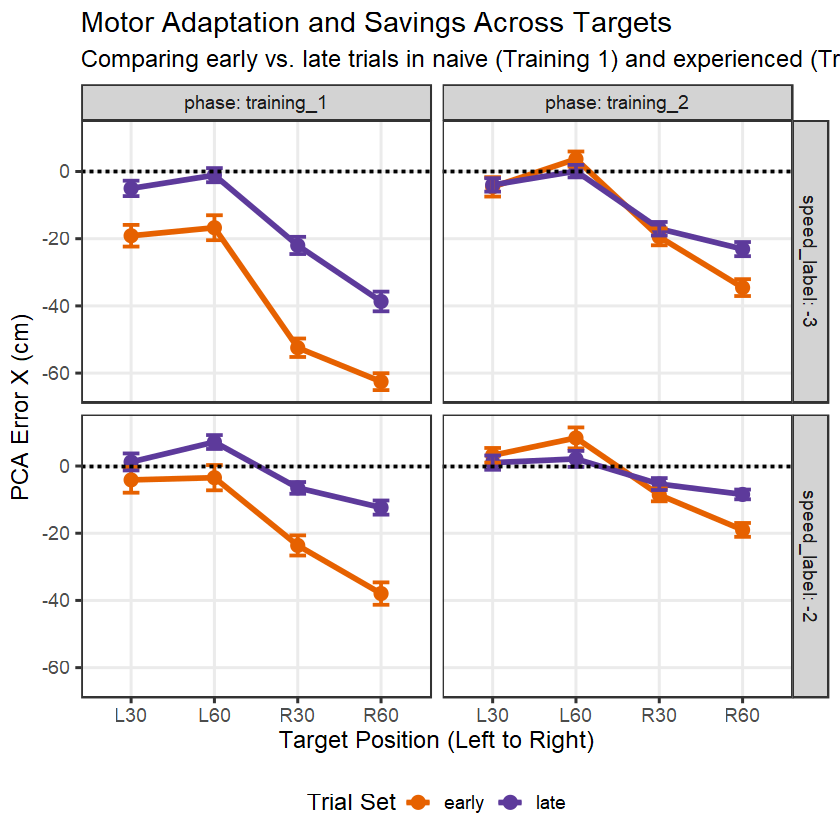

In [79]:
library(afex)
library(emmeans) 

setwd("C:/Users/jacob/water_current_MA/data/dual_generalization")
dir <- getwd()
print(paste("Working directory:", dir))

df_dual <- read.csv("early_late_phase_PCA_error_projectile_experiment _S1-projectile_experiment_etc_speed_neg3_0_neg2_0.csv")

# Ensure factors
df_dual$ppid_full <- factor(df_dual$ppid_full)
df_dual$speed_label <- factor(df_dual$speed_label)

for (s in speeds_list) {
  
  df_subset <- df_dual[df_dual$speed_label == s,]
  df_subset <- droplevels(df_subset) 
    
  mm_gen <- afex::mixed(PCA_error_X_cm ~ target_x_label * phase * trial_set + (1|ppid_full),
                        data = df_subset, method = "S")
  
  print(afex::nice(mm_gen))
  
  emm_mm_gen <- emmeans(mm_gen, ~ phase)
  emm_by_set <- emmeans(mm_gen, ~ trial_set)
  emm_by_target <- emmeans(mm_gen, ~ phase | target_x_label)
  emm_phase_trial <- emmeans(mm_gen, ~ trial_set | phase)
  emm_3way <- emmeans(mm_gen, ~ trial_set | phase * target_x_label)
  
  print(pairs(emm_mm_gen, infer = TRUE))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))
  print(pairs(emm_by_set, adjust = "holm", infer = TRUE))
  print(pairs(emm_3way, adjust = "holm", infer = TRUE))

}

# GENERATE THE PLOTS ---

# Calculate means and standard errors
plot_data <- df_dual %>%
  group_by(speed_label, phase, trial_set, target_x_label) %>%
  summarise(
    mean_error = mean(PCA_error_X_cm, na.rm = TRUE),
    se_error = sd(PCA_error_X_cm, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# Create the 3-Way Interaction Plot
adaptation_plot <- ggplot(plot_data, aes(x = target_x_label, y = mean_error, color = trial_set, group = trial_set)) +
  # Draw the lines connecting early to late
  geom_line(linewidth = 1.2) +
  # Add the points with error bars
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = mean_error - se_error, ymax = mean_error + se_error), width = 0.2, linewidth = 0.8) +
  # Create a grid: Speeds on the Y axis, Phases on the X axis
  facet_grid(speed_label ~ phase, labeller = label_both) + 
  # Add the "perfect aim" baseline
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
  # Clean up the theme
  theme_bw(base_size = 14) +
  scale_color_manual(values = c("early" = "#E66100", "late" = "#5D3A9B")) + # Colorblind friendly palette
  labs(
    title = "Motor Adaptation and Savings Across Targets",
    subtitle = "Comparing early vs. late trials in naive (Training 1) and experienced (Training 2) phases",
    x = "Target Position (Left to Right)", 
    y = "PCA Error X (cm)", 
    color = "Trial Set"
  ) +
  theme(
    legend.position = "bottom",
    strip.background = element_rect(fill = "lightgray"),
    panel.grid.minor = element_blank()
  )

# Display the plot
print(adaptation_plot)
